## Phase 3 - Anti Spoof Model Training

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

zip_path = '/content/drive/MyDrive/Applied ML/Group_assignment/LCC_FASD.zip'

if os.path.exists(zip_path):
    size = os.path.getsize(zip_path) / (1024**3)
    print(f'Found: {size:.2f} GB')
    with zipfile.ZipFile(zip_path, 'r') as z:
        names = z.namelist()
        print(f'Total files: {len(names)}')
        print('First 15:')
        for n in names[:15]:
            print(f'  {n}')
else:
    print('Not found — checking Drive...')
    for root, dirs, files in os.walk('/content/drive/MyDrive/Applied ML'):
        for f in files:
            print(os.path.join(root, f))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found: 4.84 GB
Total files: 18827
First 15:
  LCC_FASD_development/real/AGL752VM_id147_s0_105.png
  LCC_FASD_development/real/AGL752VM_id147_s0_120.png
  LCC_FASD_development/real/AGL752VM_id147_s0_135.png
  LCC_FASD_development/real/AGL752VM_id147_s0_15.png
  LCC_FASD_development/real/AGL752VM_id147_s0_150.png
  LCC_FASD_development/real/AGL752VM_id147_s0_30.png
  LCC_FASD_development/real/AGL752VM_id147_s0_45.png
  LCC_FASD_development/real/AGL752VM_id147_s0_60.png
  LCC_FASD_development/real/AGL752VM_id147_s0_75.png
  LCC_FASD_development/real/AGL752VM_id147_s0_90.png
  LCC_FASD_development/real/FT720P_id0_s0_105.png
  LCC_FASD_development/real/FT720P_id0_s0_120.png
  LCC_FASD_development/real/FT720P_id0_s0_135.png
  LCC_FASD_development/real/FT720P_id0_s0_15.png
  LCC_FASD_development/real/FT720P_id0_s0_150.png


In [3]:
import os, zipfile

zip_path = '/content/drive/MyDrive/Applied ML/Group_assignment/LCC_FASD.zip'

os.makedirs('/content/lcc_fasd', exist_ok=True)
print('Extracting...')
os.system(f"unzip -q '{zip_path}' -d '/content/lcc_fasd/'")
print('Done!')

# Count real and fake images
for split in ['LCC_FASD_development', 'LCC_FASD_evaluation']:
    for label in ['real', 'fake']:
        path  = f'/content/lcc_fasd/{split}/{label}'
        if os.path.exists(path):
            count = len(os.listdir(path))
            print(f'{split}/{label}: {count} images')

Extracting...
Done!
LCC_FASD_development/real: 405 images
LCC_FASD_evaluation/real: 314 images


In [4]:
import os

# Check full structure
for root, dirs, files in os.walk('/content/lcc_fasd'):
    level = root.replace('/content/lcc_fasd', '').count(os.sep)
    if level > 3: continue
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/ ({len(files)} files)')

lcc_fasd/ (0 files)
  LCC_FASD_training/ (0 files)
    real/ (1223 files)
    spoof/ (7076 files)
  LCC_FASD_evaluation/ (0 files)
    real/ (314 files)
    spoof/ (7266 files)
  LCC_FASD_development/ (0 files)
    real/ (405 files)
    spoof/ (2543 files)


## PHASE 3


In [6]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

MODEL_DIR = '/content/drive/MyDrive/Applied ML/models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Use training split
REAL_DIR  = '/content/lcc_fasd/LCC_FASD_training/real'
FAKE_DIR  = '/content/lcc_fasd/LCC_FASD_training/spoof'

# Eval split for validation
REAL_VAL  = '/content/lcc_fasd/LCC_FASD_development/real'
FAKE_VAL  = '/content/lcc_fasd/LCC_FASD_development/spoof'

print(f'Train real : {len(os.listdir(REAL_DIR))}')
print(f'Train spoof: {len(os.listdir(FAKE_DIR))}')
print(f'Val real   : {len(os.listdir(REAL_VAL))}')
print(f'Val spoof  : {len(os.listdir(FAKE_VAL))}')

Mounted at /content/drive
Device: cuda
Train real : 1223
Train spoof: 7076
Val real   : 405
Val spoof  : 2543


In [8]:
SPOOF_TRAIN_TF = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.3, 0.3, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

SPOOF_EVAL_TF = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


class SpoofDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform):
        self.transform = transform
        self.samples   = []
        for f in os.listdir(real_dir):
            if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                self.samples.append((os.path.join(real_dir, f), 1))
        for f in os.listdir(fake_dir):
            if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                self.samples.append((os.path.join(fake_dir, f), 0))
        random.shuffle(self.samples)
        print(f'Dataset: {len(self.samples)} samples '
              f'({sum(1 for _,l in self.samples if l==1)} real, '
              f'{sum(1 for _,l in self.samples if l==0)} spoof)')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return self.transform(Image.open(path).convert('RGB')), label


train_ds = SpoofDataset(REAL_DIR, FAKE_DIR, SPOOF_TRAIN_TF)
val_ds   = SpoofDataset(REAL_VAL, FAKE_VAL, SPOOF_EVAL_TF)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)

print(f'\nTrain loader: {len(train_ds)} samples')
print(f'Val loader  : {len(val_ds)} samples')

Dataset: 8299 samples (1223 real, 7076 spoof)
Dataset: 2948 samples (405 real, 2543 spoof)

Train loader: 8299 samples
Val loader  : 2948 samples


In [9]:
class AntiSpoofModel(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        for i, layer in enumerate(base.features):
            if i < 12:
                for p in layer.parameters():
                    p.requires_grad = False
        self.features   = base.features
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)).flatten(1))


spoof_model = AntiSpoofModel().to(device)
print(f'Trainable params: {sum(p.numel() for p in spoof_model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 123MB/s]


Trainable params: 2,246,338


In [10]:
SPOOF_EPOCHS = 10
spoof_crit   = nn.CrossEntropyLoss()
spoof_opt    = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, spoof_model.parameters()),
    lr=5e-4, weight_decay=1e-4)
spoof_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(
    spoof_opt, T_max=SPOOF_EPOCHS)

best_acc = 0.0
history  = []

for ep in range(1, SPOOF_EPOCHS + 1):
    spoof_model.train()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in tqdm(train_loader, desc=f'[SPOOF] Ep {ep}/{SPOOF_EPOCHS}'):
        imgs, labels = imgs.to(device), labels.to(device)
        logits       = spoof_model(imgs)
        loss         = spoof_crit(logits, labels)
        spoof_opt.zero_grad()
        loss.backward()
        spoof_opt.step()
        total_loss  += loss.item() * len(imgs)
        correct     += (logits.argmax(1) == labels).sum().item()
        n           += len(imgs)
    spoof_sched.step()

    spoof_model.eval()
    vcorrect, vn = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            vcorrect    += (spoof_model(imgs).argmax(1) == labels).sum().item()
            vn          += len(imgs)

    val_acc = vcorrect / vn
    history.append({'loss': total_loss/n, 'tr_acc': correct/n, 'val_acc': val_acc})
    print(f'Ep {ep:02d} | loss={total_loss/n:.4f} | train={correct/n:.3f} | val={val_acc:.3f}')

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(spoof_model.state_dict(),
                   os.path.join(MODEL_DIR, 'spoof_model_best.pth'))
        print(f'  ✅ Saved (val={val_acc:.3f})')

print(f'\nBest val accuracy: {best_acc:.3f}')

[SPOOF] Ep 1/10: 100%|██████████| 260/260 [01:53<00:00,  2.29it/s]


Ep 01 | loss=0.2328 | train=0.903 | val=0.694
  ✅ Saved (val=0.694)


[SPOOF] Ep 2/10: 100%|██████████| 260/260 [01:51<00:00,  2.34it/s]


Ep 02 | loss=0.1381 | train=0.946 | val=0.888
  ✅ Saved (val=0.888)


[SPOOF] Ep 3/10: 100%|██████████| 260/260 [01:50<00:00,  2.35it/s]


...

Ep 08 | loss=0.0332 | train=0.987 | val=0.953


[SPOOF] Ep 9/10: 100%|██████████| 260/260 [01:49<00:00,  2.37it/s]


Ep 09 | loss=0.0338 | train=0.988 | val=0.959


[SPOOF] Ep 10/10: 100%|██████████| 260/260 [01:48<00:00,  2.39it/s]


Ep 10 | loss=0.0260 | train=0.991 | val=0.960

Best val accuracy: 0.967


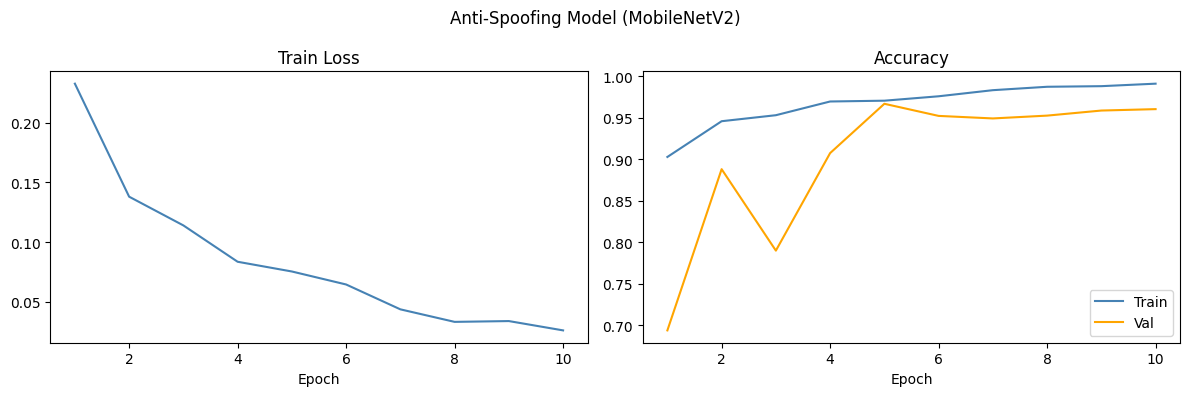

Model saved: /content/drive/MyDrive/Applied ML/models/spoof_model_best.pth
✅ Phase 3 complete.


In [11]:
epochs = range(1, SPOOF_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs, [h['loss']    for h in history], color='steelblue')
ax1.set_title('Train Loss'); ax1.set_xlabel('Epoch')
ax2.plot(epochs, [h['tr_acc']  for h in history], label='Train', color='steelblue')
ax2.plot(epochs, [h['val_acc'] for h in history], label='Val',   color='orange')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.suptitle('Anti-Spoofing Model (MobileNetV2)')
plt.tight_layout()
plt.show()

print(f'Model saved: {os.path.join(MODEL_DIR, "spoof_model_best.pth")}')
print('✅ Phase 3 complete.')